# ZDT2 Results

In [5]:
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_zdt2_front_true
from deap import benchmarks
import multiprocessing
from functools import partial
import matplotlib.pyplot as plt
# 1. Parâmetros (Substituindo as antigas variáveis globais)
IND_SIZE = 30
NPOP = 100
NGEN = 200
NOBJ = 2
NUM_TABLES = int((1 << NOBJ))
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1] * NOBJ

func_zdt2_segura = partial(benchmarks.zdt2)
toolbox = build_toolbox(func_zdt2_segura, IND_SIZE, NPOP, NOBJ)
pareto_real = generate_zdt2_front_true(10000, IND_SIZE)
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    reset = 10
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[[0.7575291204999937, 0.42614963159450614], [0.02168757670040533, 0.999529649016864], [0.6861870550949509, 0.5291473254201188], [0.16105435661953216, 0.9740614942138686], [0.33824709282726495, 0.8855889041939036], [0.28312400062178367, 0.9198408002719163], [0.7515039097959418, 0.43524187356141286], [0.9284186288319856, 0.13803884963773583], [0.7975625138391814, 0.3638940365185256], [0.06508301625063773, 0.9957642009957193], [0.008276704605551743, 0.9999314961608724], [0.03569232202735151, 0.9987260581482958], [0.17292429449927538, 0.9700971883719279], [0.36699823935755327, 0.8653122923084561], [0.6568658673301587, 0.5685272323365983], [0.7545721591876579, 0.43062085657887594], [0.5116828223898754, 0.7381806892711312], [0.232361463763206, 0.9460081501578204], [0.17447876556303676, 0.9695571603675989], [0.4089625381458174, 0.8327496423933308], [0.5278651869300842, 0.7213583444272673], [0.5575625970521797, 0.6891239503684288], [0.23130838976083978, 0.9464964288262474], [0.0333097107939944

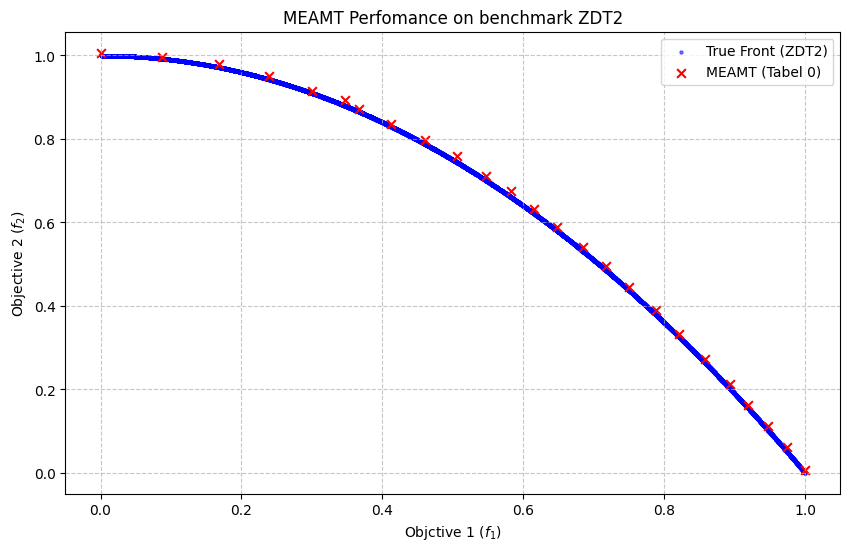

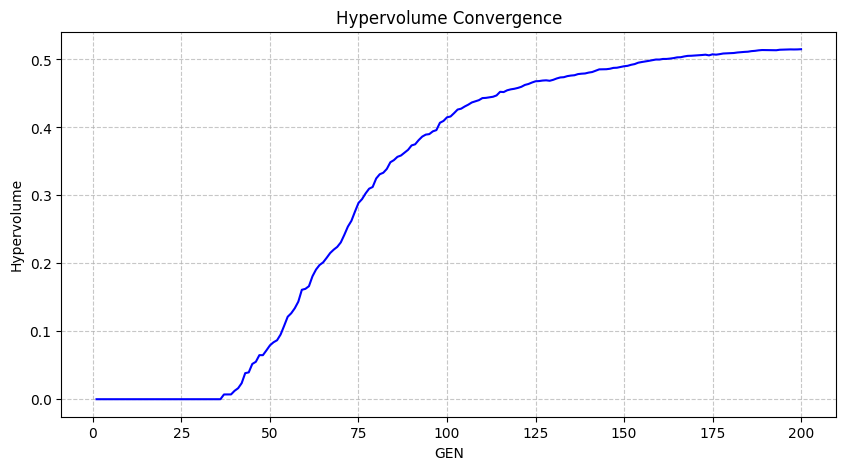

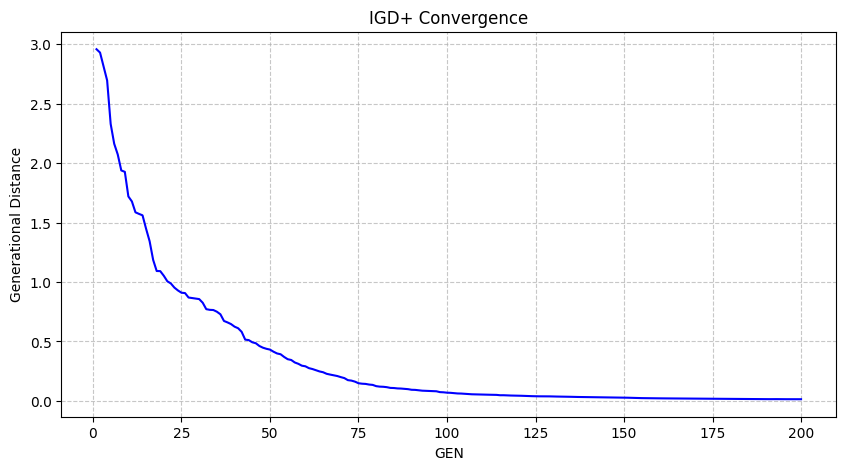

In [ ]:
f1_approx = [ind.fitness.values[0] for ind in tabelas[0]]
f2_approx = [ind.fitness.values[1] for ind in tabelas[0]]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT2)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='MEAMT (Tabel 0)')

plt.title("MEAMT Perfomance on benchmark ZDT2")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()